## Dataset Information

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are munch more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods. Two datasets were combined and few values were randomly removed.

#### Attribute Information:
Input variables (based on physicochemical tests): \
1 - fixed acidity \
2 - volatile acidity \
3 - citric acid \
4 - residual sugar \
5 - chlorides \
6 - free sulfur dioxide \
7 - total sulfur dioxide \
8 - density \
9 - pH \
10 - sulphates \
11 - alcohol \
Output variable (based on sensory data): \
12 - quality (score between 0 and 10)

## Import modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load the dataset

In [2]:
df = pd.read_csv('winequality.csv')
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Preprocessing the data

In [5]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [6]:
# Fill the missing values
for col, value in df.items():
    if col != 'type':
        df[col] = value.fillna(df[col].mean())

In [7]:
df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


## EDA

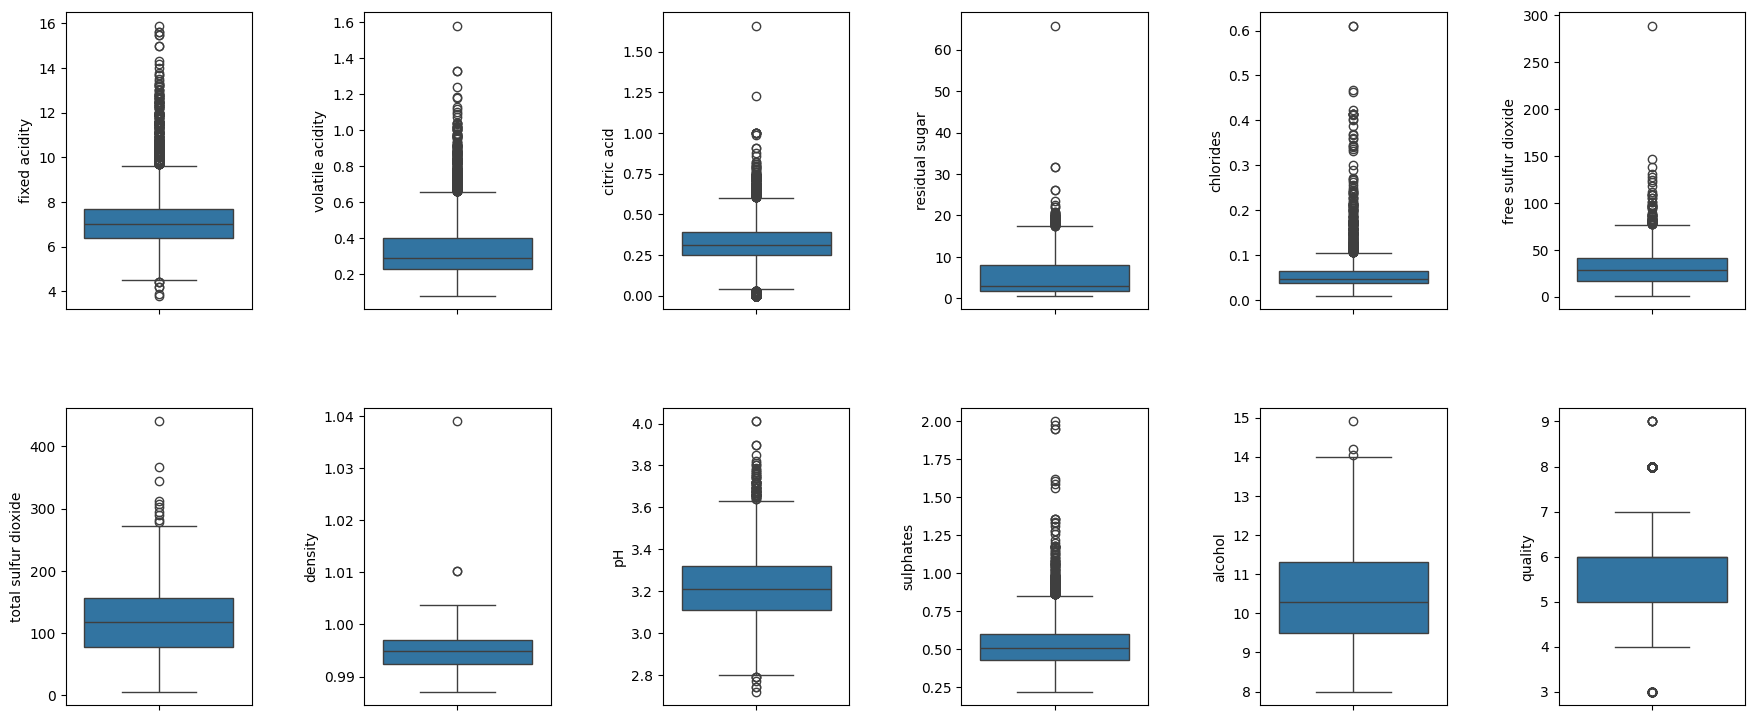

In [8]:
# Create box plot
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(20,10))
fig.tight_layout(pad=10, w_pad=5, h_pad=5)
index = 0
ax = ax.flatten() # 2D to 1D
for col, value in df.items():
    if col != 'type':
        sns.boxplot(y=col, data=df, ax=ax[index])
        index += 1

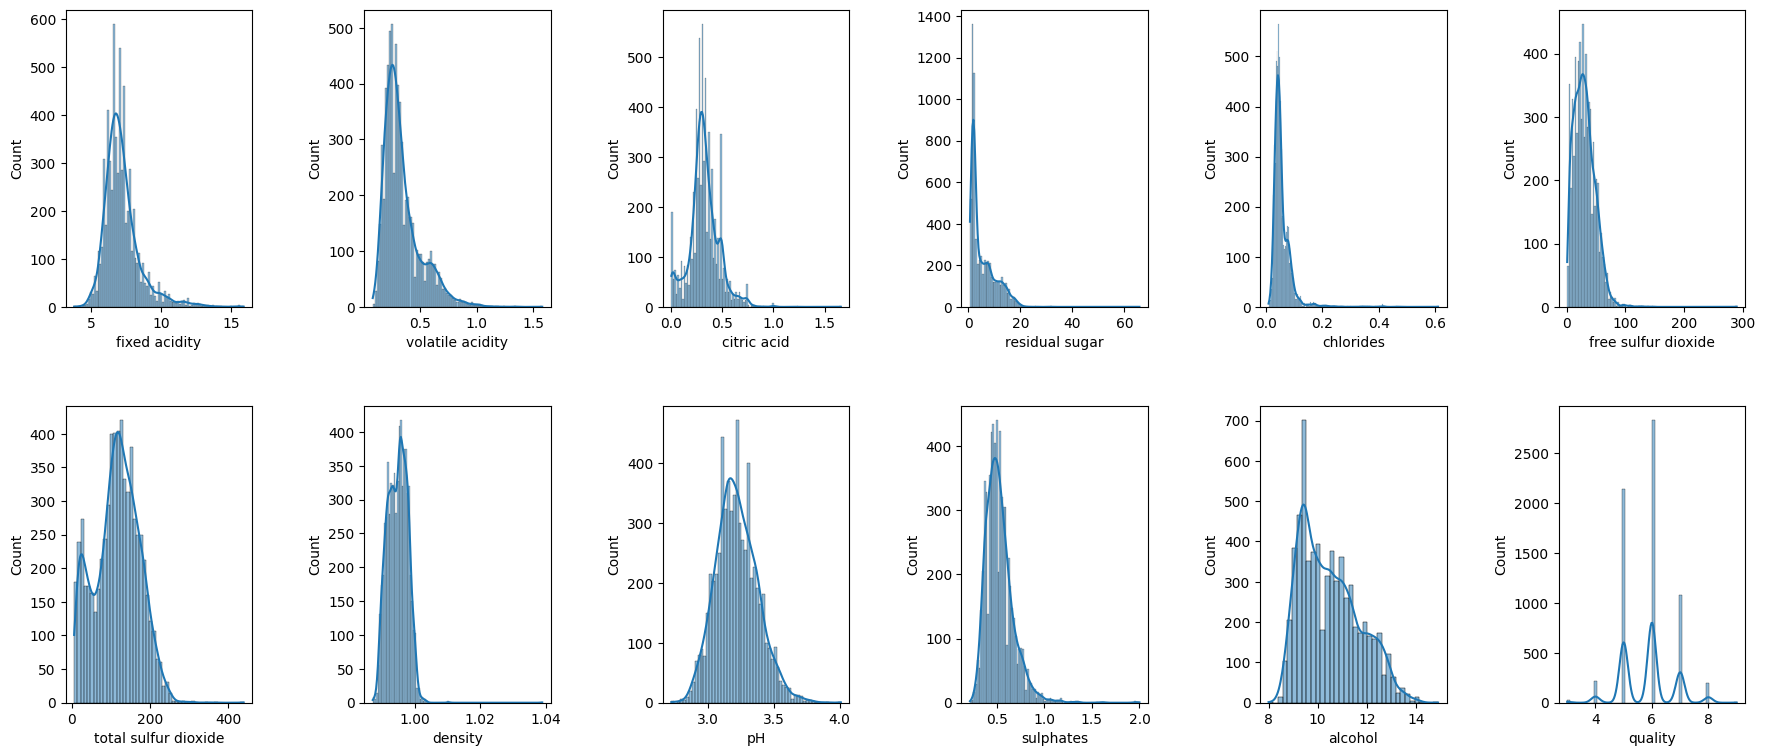

In [9]:
# Create hist plot
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(20,10))
fig.tight_layout(pad=10, w_pad=5, h_pad=5)
index = 0
ax = ax.flatten() # 2D to 1D
for col, value in df.items():
    if col != 'type':
        sns.histplot(x=col, data=df, ax=ax[index], kde=True)
        index += 1

<Axes: xlabel='free sulfur dioxide', ylabel='Count'>

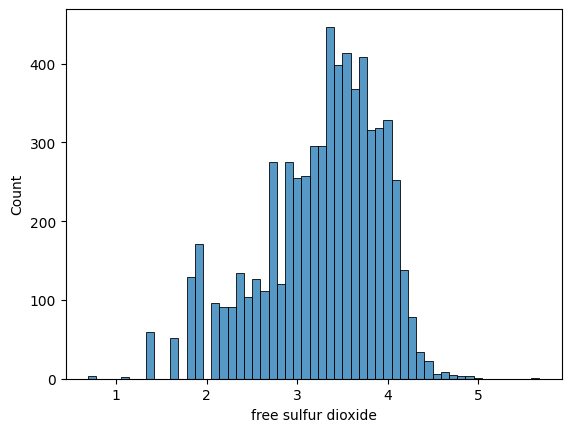

In [10]:
# >> Note: 'free sulfur dioxide' has wide range and skewed distribution
# Log transformation
df['free sulfur dioxide'] = np.log(1 + df['free sulfur dioxide'])
sns.histplot(df['free sulfur dioxide'])

<Axes: xlabel='type', ylabel='count'>

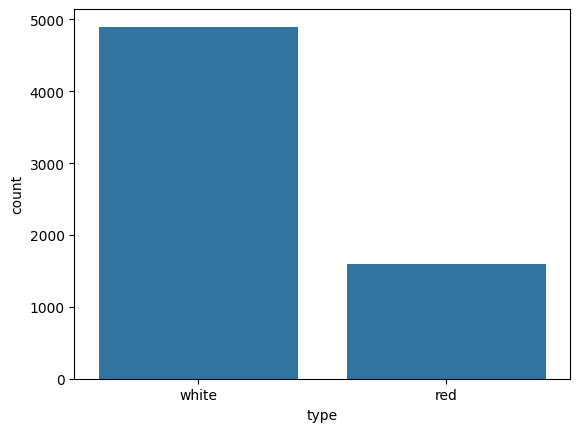

In [11]:
sns.countplot(x=df['type'])

<Axes: xlabel='quality', ylabel='count'>

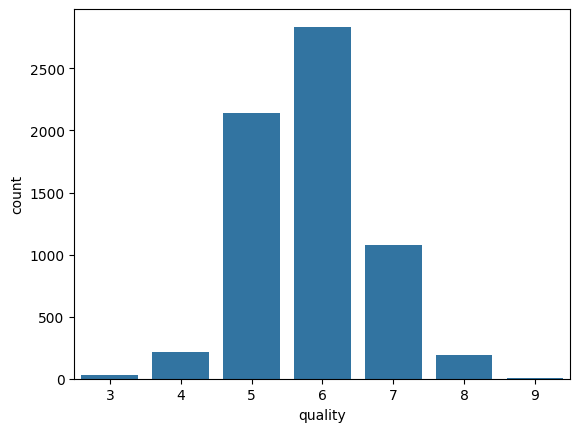

In [12]:
sns.countplot(x=df['quality'])
# >> Note: The plot shows class imbalance

### Correlation matrix

<Axes: >

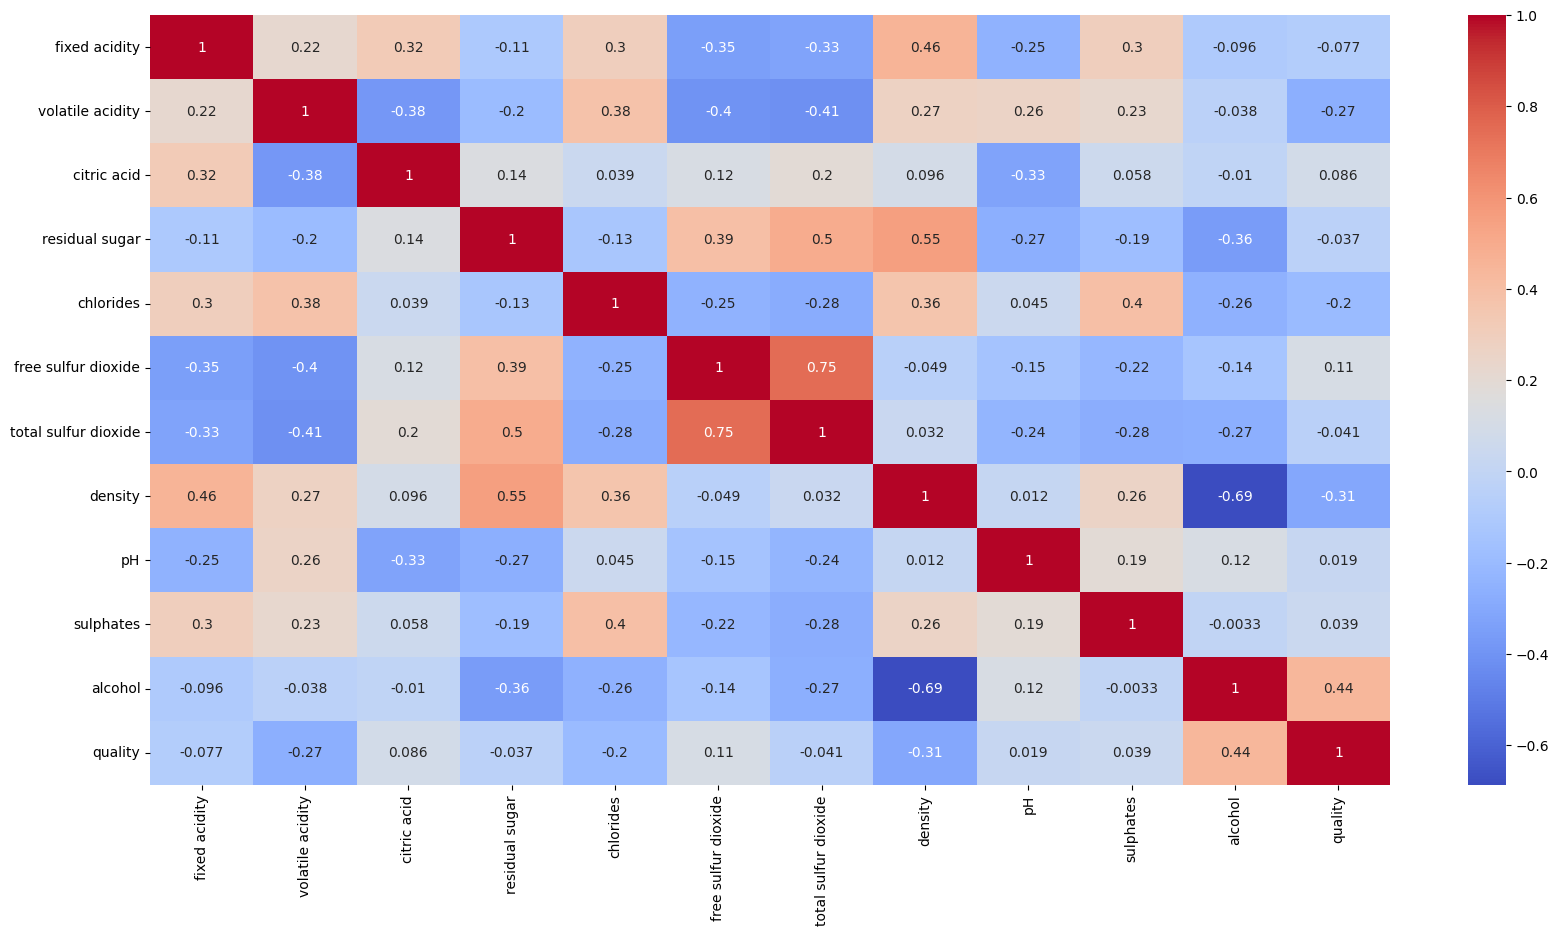

In [13]:
# Exclude non-numeric columns for correlation matrix calculation
plt.figure(figsize=(20,10))
sns.heatmap(df.drop('type', axis=1).corr(), annot=True, cmap='coolwarm')
# >> Note: The heatmap shows a strong positive correlation between quality and alcohol.
# There are also strong correlation between free and total sulfur dioxide (positive), alcohol and density (negative)
# -> We can remove free sulfur dioxide and density

## Input split

In [14]:
X = df.drop(['type', 'quality'], axis=1)
y = df['quality']

## Handling Class Imbalance

In [15]:
y.value_counts()

,count
quality,
6,2836
5,2138
7,1079
4,216
8,193
3,30
9,5


In [16]:
from imblearn.over_sampling import SMOTE # Simple strategy
oversample = SMOTE(k_neighbors=4)
# Transform the dataset
X, y = oversample.fit_resample(X, y)

In [17]:
y.value_counts()

,count
quality,
6,2836
5,2836
7,2836
8,2836
4,2836
3,2836
9,2836


## Model training

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score

def classify(model, X, y):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  model.fit(X_train, y_train)
  print("Accuracy: ", model.score(X_test, y_test)*100)

  score = cross_val_score(model, X, y, cv=5)
  print("Cross validation score: ", np.mean(score)*100)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [20]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train and evaluate Logistic Regression model with scaled data
model = LogisticRegression()
classify(model, X_scaled, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:  51.196172248803826


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross validation score:  48.38302884831908


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
model = DecisionTreeClassifier()
classify(model, X, y)

Accuracy:  81.18861747670611
Cross validation score:  75.87655844926093


In [22]:
model = RandomForestClassifier()
classify(model, X, y)

Accuracy:  89.09594560564089
Cross validation score:  82.87333672906912


In [23]:
model = ExtraTreesClassifier()
classify(model, X, y)

Accuracy:  89.87660538907076
Cross validation score:  83.7296850529056
